In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import colormaps
list(colormaps)
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("housePrice.csv")

In [3]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [4]:
df.tail()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67
3478,82,2,False,True,True,Parand,3.600000e+08,12000.00


In [5]:
df.nunique()

Area          243
Room            6
Parking         2
Warehouse       2
Elevator        2
Address       192
Price         934
Price(USD)    932
dtype: int64

In [6]:
df.isna().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [7]:
cf = df[df['Address'].notna()]

In [8]:
cf.tail()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67
3478,82,2,False,True,True,Parand,3.600000e+08,12000.00


In [9]:
cf.isna().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

In [10]:
duplicates = cf[cf.duplicated()]

In [11]:
len(duplicates)

208

In [12]:
cf.drop_duplicates(inplace=True)

In [13]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3248 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3248 non-null   object 
 1   Room        3248 non-null   int64  
 2   Parking     3248 non-null   bool   
 3   Warehouse   3248 non-null   bool   
 4   Elevator    3248 non-null   bool   
 5   Address     3248 non-null   object 
 6   Price       3248 non-null   float64
 7   Price(USD)  3248 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 161.8+ KB


In [14]:
cf.columns = [col.lower() for col in cf.columns]
print(cf.columns)

Index(['area', 'room', 'parking', 'warehouse', 'elevator', 'address', 'price',
       'price(usd)'],
      dtype='object')


In [15]:
cf['area'] = cf['area'].str.replace(" ", "")
cf['area'] = cf['area'].str.replace(",", "")

In [16]:
cf['area'] = cf['area'].astype("int64")
cf['elevator'] = cf['elevator'].astype("int")
cf['parking'] = cf['parking'].astype("int")

[Text(0.5, 0, 'meters'), Text(0, 0.5, 'abundance'), Text(0.5, 1.0, 'area')]

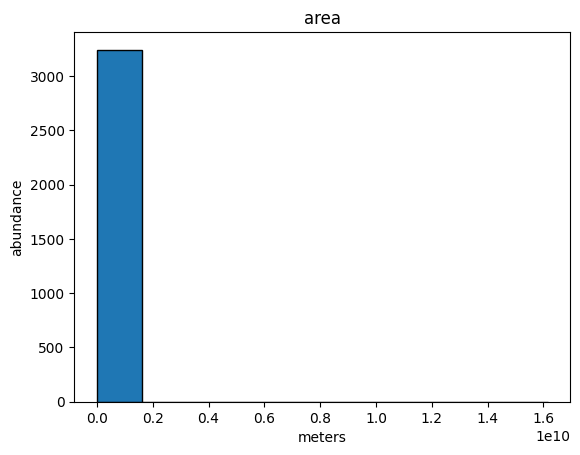

In [17]:
fig , ax = plt.subplots()
ax.hist(cf['area'], edgecolor = "black" , bins = 10)
ax.set(xlabel= "meters", ylabel = "abundance" , title = 'area')

[Text(0.5, 0, 'rooms'), Text(0, 0.5, 'abundance'), Text(0.5, 1.0, 'roooms')]

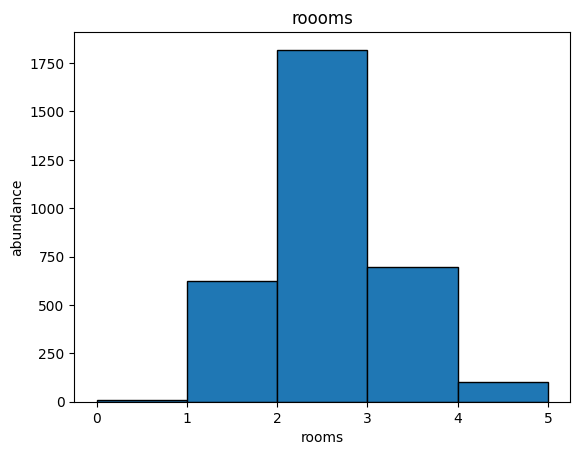

In [18]:
fig , ax = plt.subplots()
ax.hist(cf['room'] , edgecolor = "black" , bins = 5)
ax.set(xlabel= "rooms" , ylabel = "abundance" , title = 'roooms')

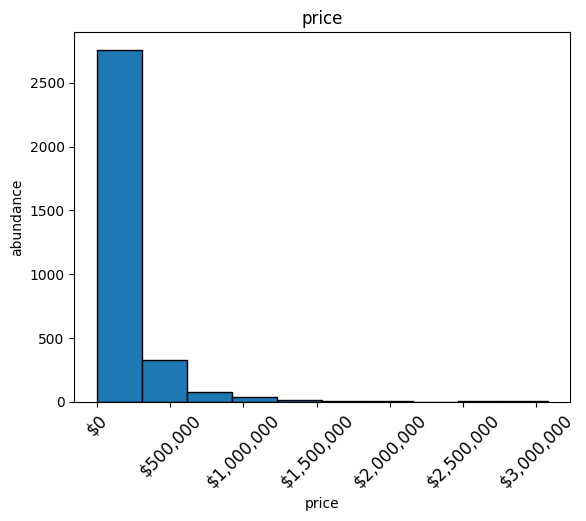

In [19]:
fig , ax = plt.subplots()
ax.hist(cf['price(usd)'] , edgecolor = "black" , bins = 10)
ax.set(xlabel= "price" , ylabel = "abundance" , title = 'price')
ax.xaxis.set_major_formatter("${x:,.0f}")
ax.tick_params(axis = "x" , labelrotation = 45 , labelsize = 12)

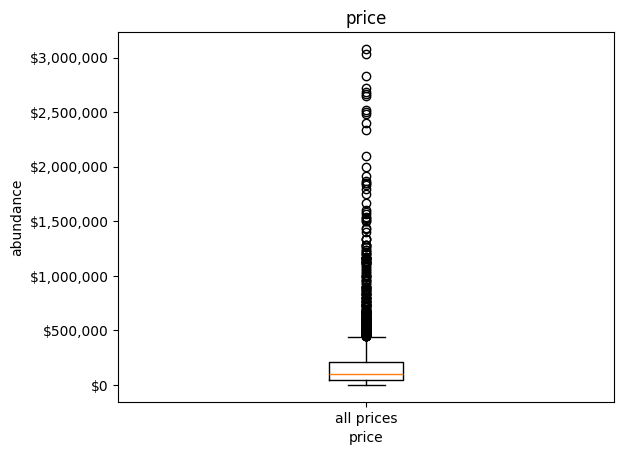

In [20]:
fig , ax = plt.subplots()
ax.boxplot(cf['price(usd)'] , labels = ["all prices"] , showfliers = True)
ax.set(xlabel= "price" , ylabel = "abundance" , title = 'price')
ax.yaxis.set_major_formatter("${x:,.0f}")

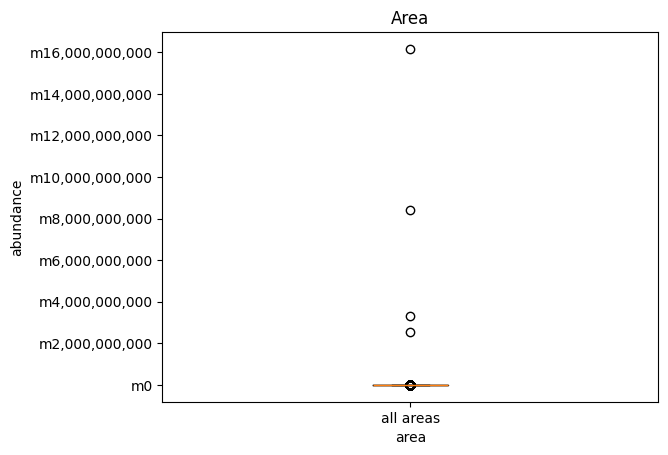

In [21]:
fig , ax = plt.subplots()
ax.boxplot(cf['area'] , labels = ["all areas"] , showfliers = True)
ax.set(xlabel= "area" , ylabel = "abundance" , title = 'Area')
ax.yaxis.set_major_formatter("m{x:,.0f}")

In [22]:
Q1 = cf.area.quantile(0.25)
Q2 = cf.area.quantile(0.50)
Q3 = cf.area.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)

np.float64(-8.0)

np.float64(200.0)

In [23]:
cf = cf[(cf['area'] >= LC) & (cf['area'] <= UC)].reset_index(drop=True)

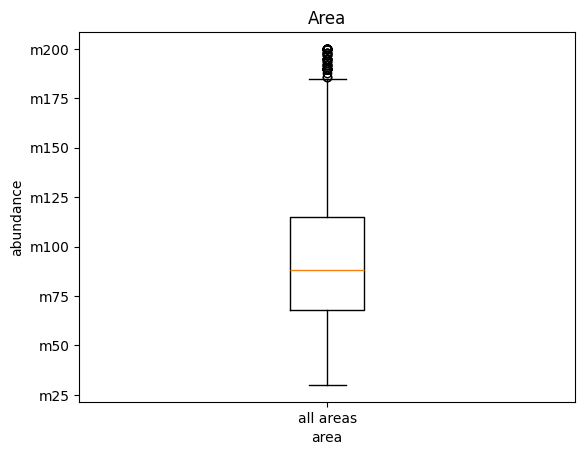

In [24]:
fig , ax = plt.subplots()
ax.boxplot(cf['area'] , labels = ["all areas"] , showfliers = True)
ax.set(xlabel= "area" , ylabel = "abundance" , title = 'Area')
ax.yaxis.set_major_formatter("m{x:,.0f}")

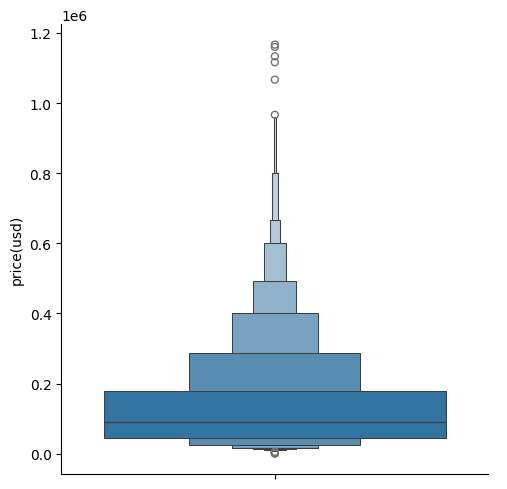

In [25]:
sns.catplot(cf , y = "price(usd)" , kind = "boxen");

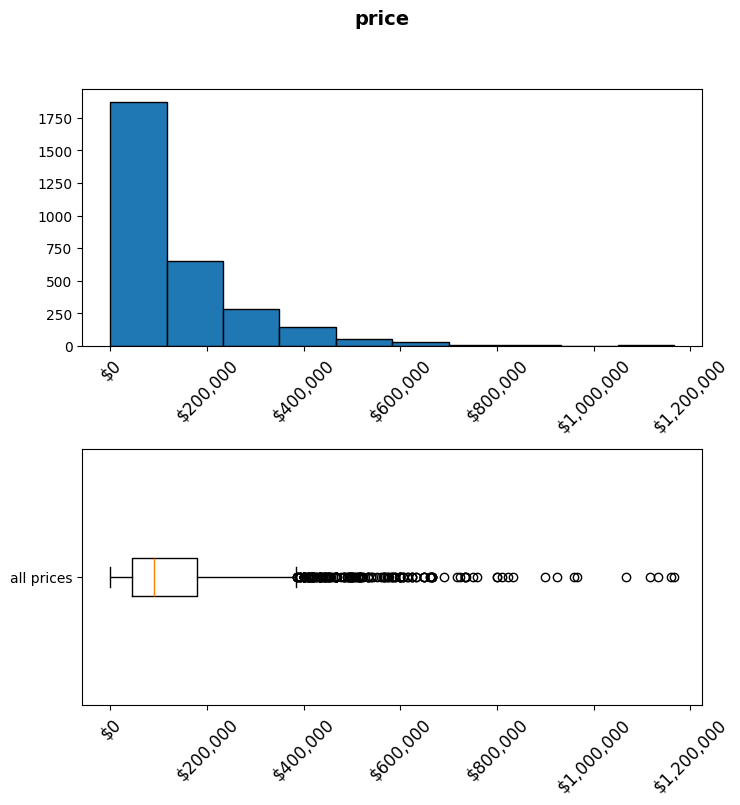

In [26]:
fig , ax = plt.subplots(2 , figsize=(8, 8))
ax[0].hist(cf['price(usd)'] , edgecolor = "black" , bins = 10);
ax[1].boxplot(cf['price(usd)'] , labels = ["all prices"] , showfliers = True , vert = False);
fig.suptitle('price', fontsize=14, fontweight='bold')
ax[0].xaxis.set_major_formatter("${x:,.0f}")
ax[0].tick_params(axis = "x" , labelrotation = 45 , labelsize = 12)
ax[1].xaxis.set_major_formatter("${x:,.0f}")
ax[1].tick_params(axis = "x" , labelrotation = 45 , labelsize = 12)
fig.subplots_adjust(hspace=0.4)
# fig.savefig("nigga.png" , transparent = False , dpi = 100 , bbox_inches = "tight")

In [27]:
avg = (cf.groupby(["room"] , as_index = False).agg({"price(usd)" : "mean" , 
                               "elevator": ["sum", "count"]}))
avg.columns = ['room', 'price_mean', 'has_elevator', 'total_elevator']
avg["elevator_common?"] = avg["has_elevator"] > (avg["total_elevator"] / 2)
avg["price_mean"] = avg["price_mean"].round(1)
avg

,room,price_mean,has_elevator,total_elevator,elevator_common?
0,0,11833.3,2,8,False
1,1,57192.6,354,624,True
2,2,110832.5,1485,1802,True
3,3,297371.1,568,601,True
4,4,259571.4,10,14,True
5,5,378547.6,1,7,False


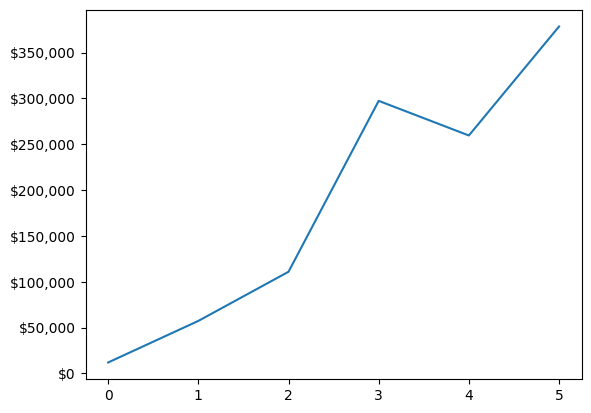

In [28]:
fig , ax = plt.subplots()
ax.plot(avg["room"] , avg["price_mean"]);
ax.yaxis.set_major_formatter("${x:,.0f}")

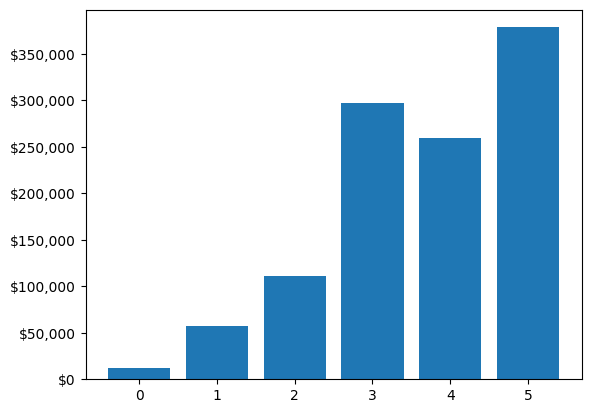

In [29]:
fig , ax = plt.subplots()
ax.bar(avg["room"] , avg["price_mean"]);
ax.yaxis.set_major_formatter("${x:,.0f}")

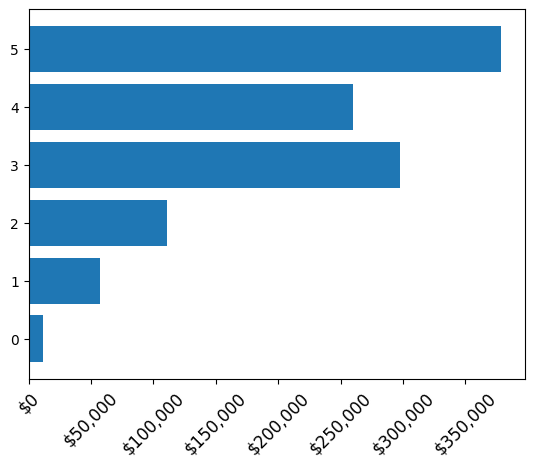

In [30]:
fig , ax = plt.subplots()
ax.barh(avg["room"] , avg["price_mean"]);
ax.xaxis.set_major_formatter("${x:,.0f}")
ax.tick_params(axis = "x" , labelrotation = 45 , labelsize = 12)

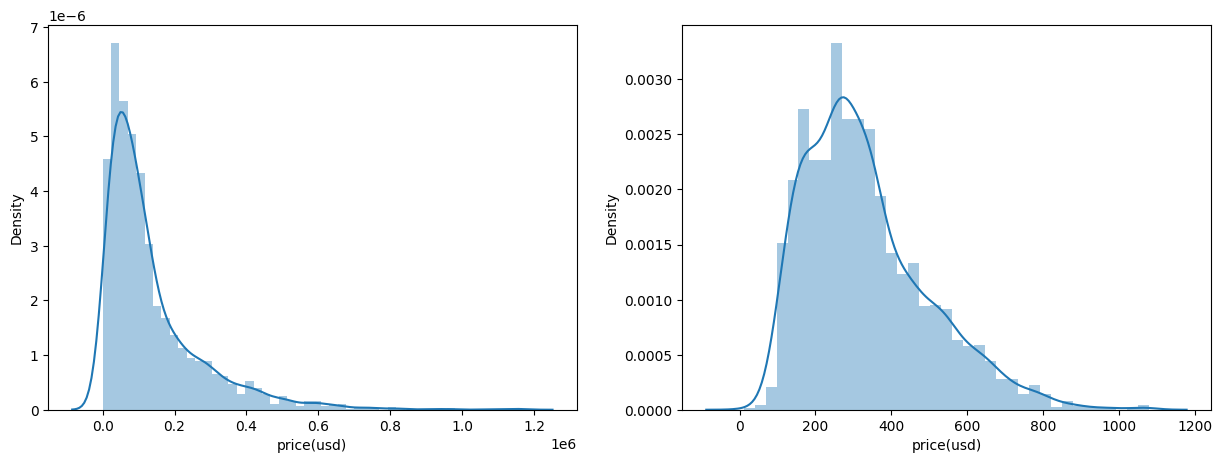

In [31]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.distplot(cf['price(usd)'], ax=axes[0])
sns.distplot(cf['price(usd)'] ** 0.5, ax=axes[1])
plt.show()

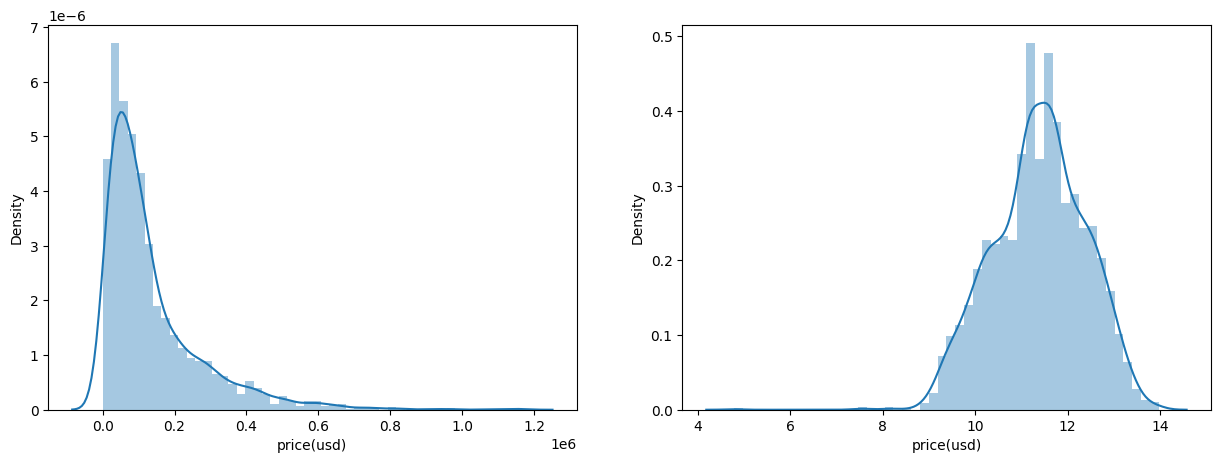

In [32]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.distplot(cf['price(usd)'], ax=axes[0])
sns.distplot(np.log(cf['price(usd)']), ax=axes[1])
plt.show()

Text(3.1, 1180000, 'the most expensive')

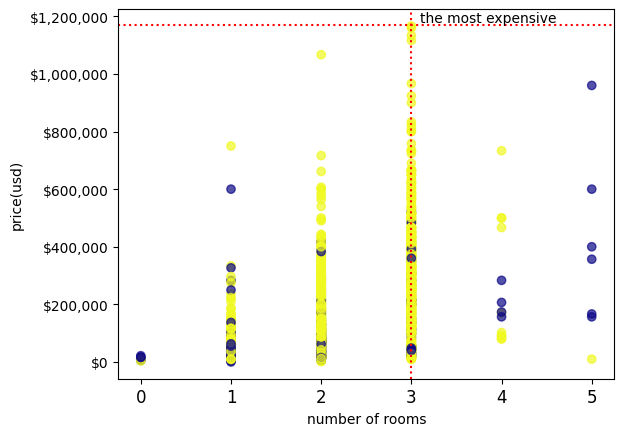

In [33]:
fig , ax = plt.subplots()
ax.scatter(x = cf["room"] , y = cf["price(usd)"] , alpha = .7,c = cf["elevator"], cmap=cm.plasma)
ax.set(xlabel='number of rooms', ylabel='price(usd)')
ax.yaxis.set_major_formatter("${x:,.0f}")
ax.tick_params(axis = "x" , labelsize = 12)
ax.tick_params(axis = "y", labelsize = 10)
ax.axvline(3 , color = "red" , linestyle = ":")
ax.axhline(1170000 , color = "red" , linestyle = ":")
ax.annotate("the most expensive" , xy = (3.1 , 1180000) , size = 10 , color = "black")

In [34]:
avv = (cf.groupby(["room"] , as_index = False).agg({"elevator": ["sum", "count"],
                               "parking": ["sum", "count"],
                               "warehouse": ["sum", "count"]}))
avv.columns = ['room','has_elevator',"total_purchases","has_parking", "tOtal_purchases", "has_warehouse", 'totaL_purchases']
avv["elevator_common?"] = avv["has_elevator"] > (avv["total_purchases"] / 2)
avv["parking_common?"] = avv["has_parking"] > (avv["tOtal_purchases"] / 2)
avv["warehouse_common?"] = avv["has_warehouse"] > (avv["totaL_purchases"] / 2)
avv["TOTAL"] = avv["total_purchases"]
avv

,room,has_elevator,total_purchases,has_parking,tOtal_purchases,has_warehouse,totaL_purchases,elevator_common?,parking_common?,warehouse_common?,TOTAL
0,0,2,8,2,8,5,8,False,False,True,8
1,1,354,624,391,624,523,624,True,True,True,624
2,2,1485,1802,1573,1802,1664,1802,True,True,True,1802
3,3,568,601,580,601,585,601,True,True,True,601
4,4,10,14,13,14,11,14,True,True,True,14
5,5,1,7,3,7,3,7,False,False,False,7


<Axes: title={'center': 'options'}>

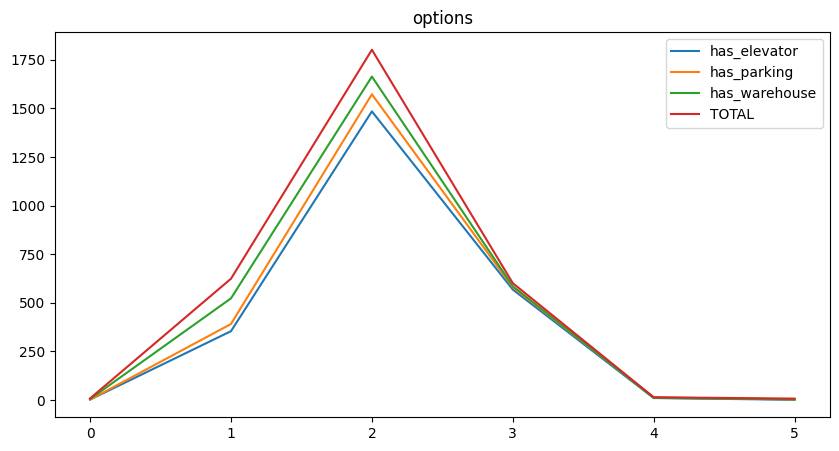

In [35]:
avv[["has_elevator" , "has_parking" , "has_warehouse" , "TOTAL"]].plot(kind = "line" , figsize = (10 , 5) , title = "options")

<Axes: title={'center': 'options'}>

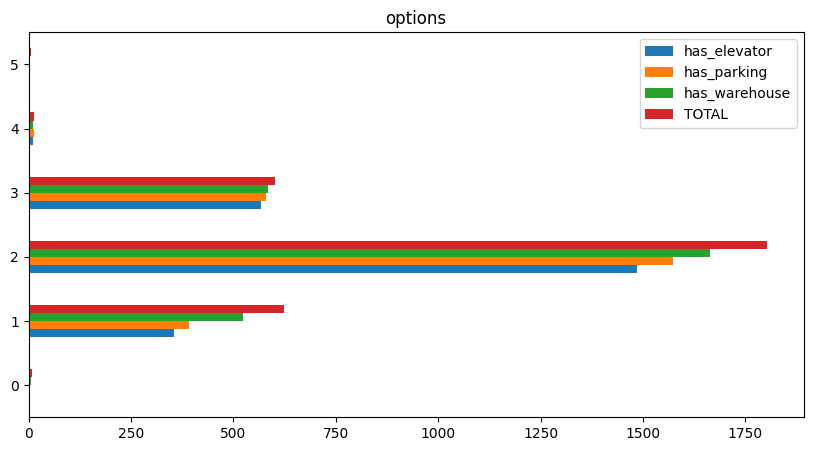

In [36]:
avv[["has_elevator" , "has_parking" , "has_warehouse" , "TOTAL"]].plot(kind = "barh" , figsize = (10 , 5) , title = "options")

<Axes: title={'center': 'options'}>

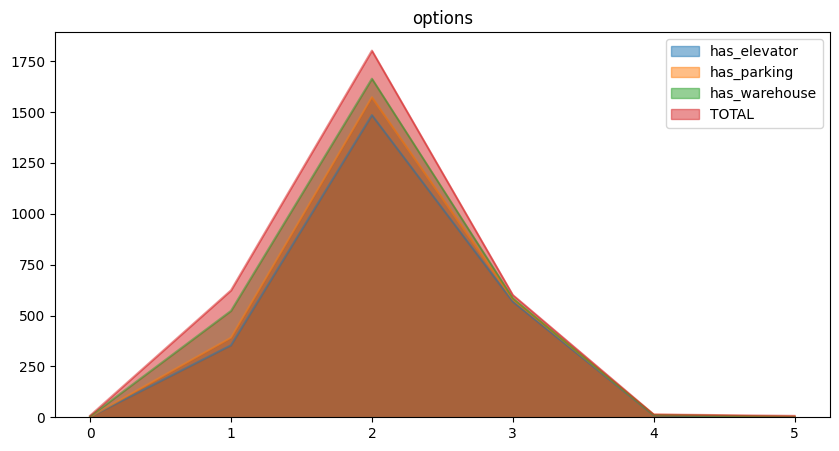

In [37]:
avv[["has_elevator" , "has_parking" , "has_warehouse" , "TOTAL"]].plot(kind = "area" , figsize = (10 , 5) , title = "options" , stacked = False)

In [67]:
len(cf)

3056

In [38]:
from sklearn.model_selection import train_test_split

x = cf.drop(columns=['price(usd)', 'address'])
y = cf['price(usd)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("training set:", x_train.shape, y_train.shape)
print("testing set:", x_test.shape, y_test.shape)

training set: (2444, 6) (2444,)
testing set: (612, 6) (612,)


In [39]:
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, StandardScaler, RobustScaler, Normalizer, Binarizer

ss = StandardScaler()
x_train_scale = ss.fit_transform(x_train)

In [40]:
x_test_scale = ss.transform(x_test)

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [42]:
model.fit(x_train_scale, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred = model.predict(x_test_scale)

In [44]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Absolute Error: 0.0021292215344200327
Mean Squared Error: 6.977612707895982e-06
R-squared Score: 0.9999999999999997
